# 📊 Week 3 — Statistical Modeling & Hypothesis Testing

## Junior Data Scientist Internship — Yuva Intern

### Research Title
**Statistical Modeling of Retail Order Value: Investigating the Influence of Order Characteristics and Customer/Product Factors**

---

## 🎯 Objective

The objective of this study is to develop a statistical model to investigate the factors associated with variation in retail order value using the cleaned Online Retail dataset.

The analysis will focus on building an invoice-level dataset and examining whether order characteristics, customer-related information, product diversity, time-related factors, and country contribute significantly to differences in order value.

The study will combine exploratory analysis, hypothesis testing, regression modeling, parameter estimation, and model diagnostics to determine statistically significant relationships while also considering practical business significance.

---

## 🔎 Research Question

**Which order, customer, product, geographic, and time-related characteristics are significantly associated with retail order value?**

---

## 🧪 Hypotheses

### Hypothesis 1 — Order Quantity

**H₀:** Total quantity associated with an order has no statistically significant relationship with order value.

**H₁:** Total quantity associated with an order has a statistically significant relationship with order value.

### Hypothesis 2 — Product Diversity

**H₀:** The number of unique products in an order has no statistically significant relationship with order value.

**H₁:** The number of unique products in an order has a statistically significant relationship with order value.

### Hypothesis 3 — Country

**H₀:** Country does not significantly contribute to differences in retail order value after accounting for other model variables.

**H₁:** Country significantly contributes to differences in retail order value after accounting for other model variables.

---

## 📌 Modeling Approach

The dependent variable will be **Order Value**, calculated at the invoice/order level.

Potential explanatory variables will include:

- Total Quantity
- Number of Unique Products
- Country
- Customer-related variables where sufficiently available
- Hour of transaction
- Day of week
- Month
- Weekend indicator

A suitable regression-based statistical model will be fitted after checking the data and relevant model assumptions.

The analysis will evaluate:

- Regression coefficients
- Standard errors
- t-statistics
- p-values
- Confidence intervals
- R² and Adjusted R²
- Model error metrics
- Residual behavior
- Multicollinearity
- Influential observations

---

## ⚠️ Important Statistical Principle

Statistical significance will not automatically be interpreted as practical or business significance.

The analysis will distinguish between **statistical association and causation**, because the dataset represents observational retail transactions rather than a controlled experiment.

---

## 💼 Business Perspective

The final interpretation will connect statistically significant relationships with potential business applications such as:

- Basket-size optimization
- Cross-selling and product bundling
- Customer segmentation
- Promotional strategy
- Inventory planning
- Revenue optimization

The analysis will also discuss limitations and possible improvements for future predictive modeling.

In [1]:
# ============================================
# STEP 3 — IMPORT LIBRARIES & LOAD DATA
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, pearsonr, spearmanr

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# Load Week 1 cleaned dataset
DATA_PATH = "../data/cleaned/Online_Retail_Cleaned.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 534,129
Columns: 8


In [2]:
import sys

!{sys.executable} -m pip install statsmodels scikit-learn


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import shapiro, pearsonr, spearmanr

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
DATA_PATH = "../data/cleaned/Online_Retail_Cleaned.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully!
Rows: 534,129
Columns: 8


In [5]:
# ============================================
# STEP 4 — CREATE INVOICE-LEVEL MODELING DATA
# ============================================

# Work on a separate copy
model_df = df.copy()

# Convert InvoiceDate to datetime
model_df["InvoiceDate"] = pd.to_datetime(model_df["InvoiceDate"], errors="coerce")

# Keep valid positive sales transactions for the primary order-value model
model_df = model_df[
    (model_df["Quantity"] > 0) &
    (model_df["UnitPrice"] > 0)
].copy()

# Create line-level revenue
model_df["LineRevenue"] = (
    model_df["Quantity"] * model_df["UnitPrice"]
)

# Create time-based variables
model_df["Hour"] = model_df["InvoiceDate"].dt.hour
model_df["DayOfWeek"] = model_df["InvoiceDate"].dt.dayofweek
model_df["Month"] = model_df["InvoiceDate"].dt.month
model_df["IsWeekend"] = (
    model_df["DayOfWeek"] >= 5
).astype(int)

# Aggregate transactions to invoice/order level
order_df = (
    model_df
    .groupby("InvoiceNo")
    .agg(
        OrderValue=("LineRevenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        AvgUnitPrice=("UnitPrice", "mean"),
        Country=("Country", "first"),
        CustomerID=("CustomerID", "first"),
        Hour=("Hour", "first"),
        DayOfWeek=("DayOfWeek", "first"),
        Month=("Month", "first"),
        IsWeekend=("IsWeekend", "first")
    )
    .reset_index()
)

print("Invoice-level modeling dataset created successfully!")
print(f"Orders: {len(order_df):,}")
print(f"Features: {order_df.shape[1]}")

Invoice-level modeling dataset created successfully!
Orders: 19,960
Features: 11


In [6]:
# ============================================
# VALIDATE MODELING DATASET
# ============================================

print("\nDataset Shape:")
print(order_df.shape)

print("\nMissing Values:")
print(order_df.isnull().sum())

print("\nDuplicate Orders:")
print(order_df["InvoiceNo"].duplicated().sum())

print("\nOrder Value Summary:")
print(order_df["OrderValue"].describe())


Dataset Shape:
(19960, 11)

Missing Values:
InvoiceNo            0
OrderValue           0
TotalQuantity        0
UniqueProducts       0
AvgUnitPrice         0
Country              0
CustomerID        1428
Hour                 0
DayOfWeek            0
Month                0
IsWeekend            0
dtype: int64

Duplicate Orders:
0

Order Value Summary:
count     19960.000000
mean        533.171884
std        1780.412288
min           0.380000
25%         151.695000
50%         303.300000
75%         493.462500
max      168469.600000
Name: OrderValue, dtype: float64


In [7]:
order_df.head()

,InvoiceNo,OrderValue,TotalQuantity,UniqueProducts,AvgUnitPrice,Country,CustomerID,Hour,DayOfWeek,Month,IsWeekend
0,536365,139.12,40,7,3.910000,United Kingdom,17850.0,8,2,12,0
1,536366,22.20,12,2,1.850000,United Kingdom,17850.0,8,2,12,0
2,536367,278.73,83,12,4.853333,United Kingdom,13047.0,8,2,12,0
3,536368,70.05,15,4,4.775000,United Kingdom,13047.0,8,2,12,0
4,536369,17.85,3,1,5.950000,United Kingdom,13047.0,8,2,12,0


## 📊 Step 5 — Distribution Analysis and Modeling Assumptions

Before fitting the regression model, the distribution of the dependent variable
(OrderValue) is examined.

The descriptive statistics indicate that the mean order value is substantially
higher than the median, suggesting a right-skewed distribution with potentially
influential high-value orders.

Because ordinary least squares regression can be sensitive to extreme values
and strongly skewed variables, the analysis will investigate the distribution
before deciding whether a logarithmic transformation is appropriate.

The following checks will be performed:

1. Distribution of OrderValue
2. Distribution of key numerical predictors
3. Identification of extreme observations
4. Log transformation assessment
5. Relationship between predictors and OrderValue

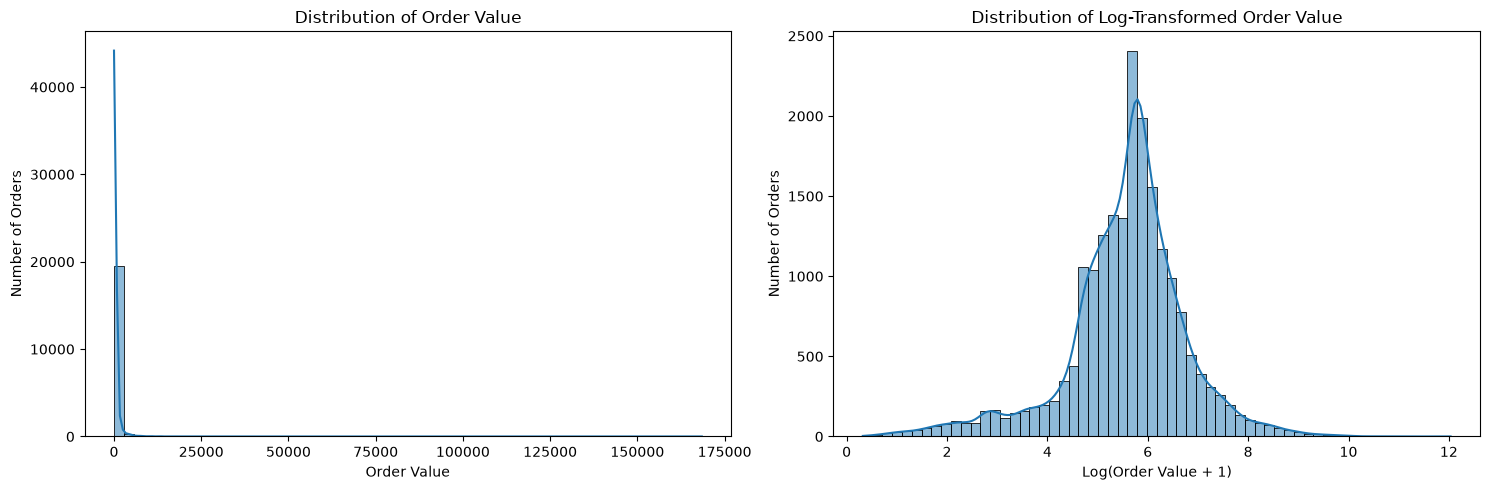

In [8]:
# ============================================
# STEP 5A — DISTRIBUTION OF ORDER VALUE
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw distribution
sns.histplot(
    order_df["OrderValue"],
    bins=60,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of Order Value")
axes[0].set_xlabel("Order Value")
axes[0].set_ylabel("Number of Orders")

# Log-transformed distribution
order_df["LogOrderValue"] = np.log1p(order_df["OrderValue"])

sns.histplot(
    order_df["LogOrderValue"],
    bins=60,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Distribution of Log-Transformed Order Value")
axes[1].set_xlabel("Log(Order Value + 1)")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [9]:
# ============================================
# STEP 5B — SKEWNESS COMPARISON
# ============================================

raw_skewness = order_df["OrderValue"].skew()
log_skewness = order_df["LogOrderValue"].skew()

print(f"Raw OrderValue skewness: {raw_skewness:.4f}")
print(f"Log-transformed skewness: {log_skewness:.4f}")

Raw OrderValue skewness: 51.0778
Log-transformed skewness: -0.6734


In [10]:
# ============================================
# STEP 5C — NUMERICAL SUMMARY
# ============================================

distribution_summary = pd.DataFrame({
    "Metric": [
        "Mean",
        "Median",
        "Standard Deviation",
        "Minimum",
        "Maximum",
        "Skewness"
    ],
    "OrderValue": [
        order_df["OrderValue"].mean(),
        order_df["OrderValue"].median(),
        order_df["OrderValue"].std(),
        order_df["OrderValue"].min(),
        order_df["OrderValue"].max(),
        raw_skewness
    ],
    "LogOrderValue": [
        order_df["LogOrderValue"].mean(),
        order_df["LogOrderValue"].median(),
        order_df["LogOrderValue"].std(),
        order_df["LogOrderValue"].min(),
        order_df["LogOrderValue"].max(),
        log_skewness
    ]
})

distribution_summary

,Metric,OrderValue,LogOrderValue
0,Mean,533.171884,5.569843
1,Median,303.300000,5.718014
2,Standard Deviation,1780.412288,1.205878
3,Minimum,0.380000,0.322083
4,Maximum,168469.600000,12.034517
5,Skewness,51.077769,-0.673428


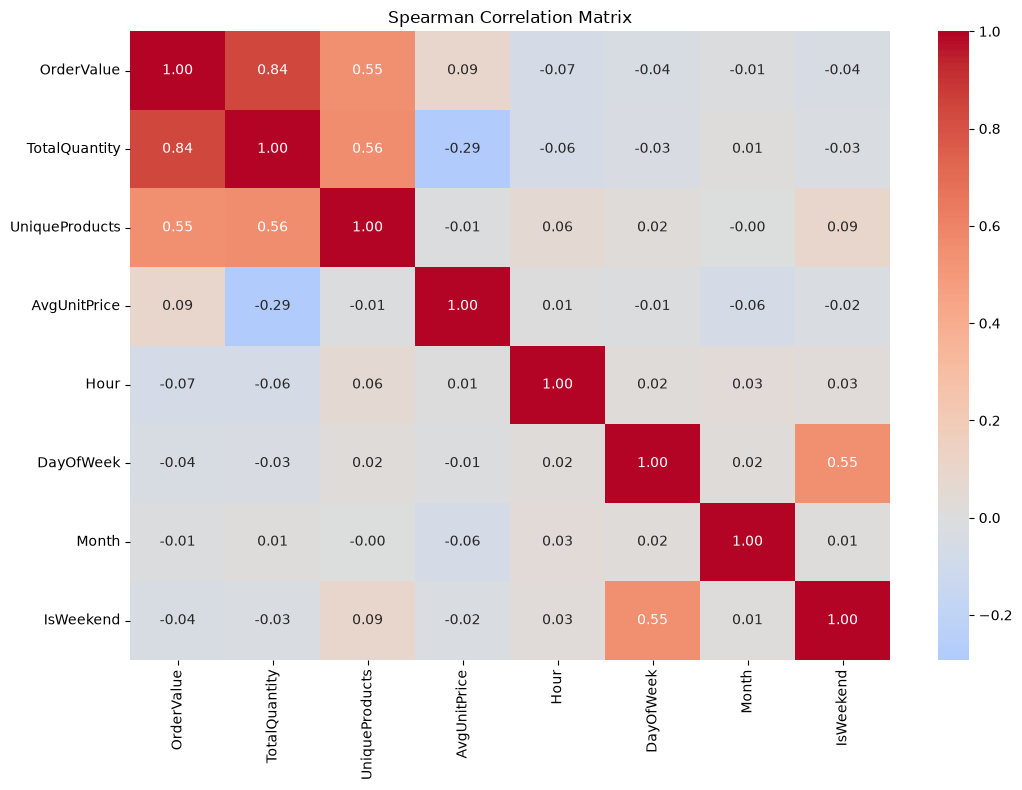

In [11]:
# ============================================
# STEP 6A — CORRELATION ANALYSIS
# ============================================

numeric_features = [
    "OrderValue",
    "TotalQuantity",
    "UniqueProducts",
    "AvgUnitPrice",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

correlation_matrix = order_df[numeric_features].corr(method="spearman")

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

In [12]:
# ============================================
# STEP 6B — MULTICOLLINEARITY USING VIF
# ============================================

vif_features = [
    "TotalQuantity",
    "UniqueProducts",
    "AvgUnitPrice",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

X_vif = order_df[vif_features].copy()

# Add intercept
X_vif = sm.add_constant(X_vif)

vif_results = pd.DataFrame()

vif_results["Feature"] = X_vif.columns

vif_results["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_results = vif_results.sort_values(
    "VIF",
    ascending=False
)

vif_results

,Feature,VIF
5,DayOfWeek,1.939935
7,IsWeekend,1.939202
2,UniqueProducts,1.040517
1,TotalQuantity,1.026266
4,Hour,1.016231
6,Month,1.001726
3,AvgUnitPrice,1.000727
0,const,1.000000


In [13]:
# ============================================
# STEP 6C — VIF INTERPRETATION
# ============================================

print("VIF Interpretation:")
print("- VIF around 1      → Very low multicollinearity")
print("- VIF below 5       → Generally acceptable")
print("- VIF 5–10          → Potential concern")
print("- VIF above 10      → High multicollinearity")

VIF Interpretation:
- VIF around 1      → Very low multicollinearity
- VIF below 5       → Generally acceptable
- VIF 5–10          → Potential concern
- VIF above 10      → High multicollinearity


In [14]:
# ============================================
# STEP 7 — PREPARE REGRESSION FEATURES
# ============================================

reg_df = order_df.copy()

# Find the 10 countries with the highest number of orders
top_countries = (
    reg_df["Country"]
    .value_counts()
    .head(10)
    .index
)

# Group less frequent countries into "Other"
reg_df["CountryGroup"] = np.where(
    reg_df["Country"].isin(top_countries),
    reg_df["Country"],
    "Other"
)

# Convert categorical variable to category type
reg_df["CountryGroup"] = reg_df["CountryGroup"].astype("category")

print("Top countries retained individually:")
print(top_countries.tolist())

print("\nCountry groups used in regression:")
print(reg_df["CountryGroup"].value_counts())

Top countries retained individually:
['United Kingdom', 'Germany', 'France', 'EIRE', 'Belgium', 'Netherlands', 'Spain', 'Portugal', 'Australia', 'Switzerland']

Country groups used in regression:
CountryGroup
United Kingdom    18019
Germany             457
France              392
Other               353
EIRE                288
Belgium              98
Netherlands          94
Spain                90
Portugal             58
Australia            57
Switzerland          54
Name: count, dtype: int64


In [15]:
# ============================================
# REGRESSION FEATURE VALIDATION
# ============================================

regression_features = [
    "LogOrderValue",
    "TotalQuantity",
    "UniqueProducts",
    "AvgUnitPrice",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend",
    "CountryGroup"
]

print("Missing values in regression variables:\n")
print(reg_df[regression_features].isnull().sum())

print("\nRegression dataset shape:")
print(reg_df[regression_features].shape)

Missing values in regression variables:

LogOrderValue     0
TotalQuantity     0
UniqueProducts    0
AvgUnitPrice      0
Hour              0
DayOfWeek         0
Month             0
IsWeekend         0
CountryGroup      0
dtype: int64

Regression dataset shape:
(19960, 9)


In [16]:
# ============================================
# ORDER VALUE BY COUNTRY GROUP
# ============================================

country_summary = (
    reg_df
    .groupby("CountryGroup", observed=True)
    .agg(
        Orders=("OrderValue", "count"),
        MeanOrderValue=("OrderValue", "mean"),
        MedianOrderValue=("OrderValue", "median"),
        TotalRevenue=("OrderValue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
)

country_summary

,Orders,MeanOrderValue,MedianOrderValue,TotalRevenue
CountryGroup,,,,
United Kingdom,18019,499.569571,299.950,9001744.094
Other,353,854.155014,439.660,301516.720
Netherlands,94,3036.663191,806.880,285446.340
EIRE,288,983.126806,651.725,283140.520
Germany,457,500.390372,354.850,228678.400
France,392,534.758597,375.135,209625.370
Australia,57,2429.014211,429.600,138453.810
Spain,90,683.984000,431.890,61558.560
Switzerland,54,1056.807407,625.965,57067.600


In [17]:
# ============================================
# STEP 8 — ORDINARY LEAST SQUARES REGRESSION
# ============================================

model_formula = """
LogOrderValue ~
TotalQuantity +
UniqueProducts +
AvgUnitPrice +
Hour +
DayOfWeek +
Month +
IsWeekend +
C(CountryGroup)
"""

ols_model = smf.ols(
    formula=model_formula,
    data=reg_df
).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:          LogOrderValue   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     468.7
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        03:01:47   Log-Likelihood:                -28704.
No. Observations:               19960   AIC:                         5.744e+04
Df Residuals:                   19942   BIC:                         5.759e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [18]:
# ============================================
# KEY MODEL STATISTICS
# ============================================

print("MODEL PERFORMANCE")
print("-" * 50)

print(f"R-squared:           {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared:  {ols_model.rsquared_adj:.4f}")
print(f"F-statistic:         {ols_model.fvalue:.4f}")
print(f"F-test p-value:      {ols_model.f_pvalue:.10f}")
print(f"AIC:                 {ols_model.aic:.2f}")
print(f"BIC:                 {ols_model.bic:.2f}")

MODEL PERFORMANCE
--------------------------------------------------
R-squared:           0.2855
Adjusted R-squared:  0.2849
F-statistic:         468.6592
F-test p-value:      0.0000000000
AIC:                 57443.24
BIC:                 57585.46


In [19]:
# ============================================
# PARAMETER ESTIMATES
# ============================================

coefficients = pd.DataFrame({
    "Coefficient": ols_model.params,
    "Std_Error": ols_model.bse,
    "t_statistic": ols_model.tvalues,
    "p_value": ols_model.pvalues,
    "CI_Lower": ols_model.conf_int()[0],
    "CI_Upper": ols_model.conf_int()[1]
})

coefficients["Significant_5pct"] = (
    coefficients["p_value"] < 0.05
)

coefficients

,Coefficient,Std_Error,t_statistic,p_value,CI_Lower,CI_Upper,Significant_5pct
Intercept,6.271367,0.141280,44.389576,0.000000e+00,5.994446,6.548288,True
C(CountryGroup)[T.Belgium],-0.017841,0.170150,-0.104854,9.164928e-01,-0.351349,0.315667,False
C(CountryGroup)[T.EIRE],0.275035,0.148068,1.857486,6.325672e-02,-0.015191,0.565262,False
C(CountryGroup)[T.France],-0.021430,0.144872,-0.147926,8.824029e-01,-0.305392,0.262532,False
C(CountryGroup)[T.Germany],-0.060140,0.143574,-0.418881,6.753074e-01,-0.341557,0.221276,False
C(CountryGroup)[T.Netherlands],0.212994,0.171282,1.243526,2.136887e-01,-0.122734,0.548722,False
C(CountryGroup)[T.Other],0.139288,0.145808,0.955280,3.394478e-01,-0.146509,0.425084,False
C(CountryGroup)[T.Portugal],0.072714,0.190491,0.381717,7.026752e-01,-0.300664,0.446091,False
C(CountryGroup)[T.Spain],0.122117,0.172897,0.706297,4.800117e-01,-0.216776,0.461009,False
C(CountryGroup)[T.Switzerland],0.183970,0.193819,0.949187,3.425370e-01,-0.195930,0.563871,False


In [20]:
# ============================================
# STEP 9A — CALCULATE MODEL RESIDUALS
# ============================================

reg_df["FittedValues"] = ols_model.fittedvalues
reg_df["Residuals"] = ols_model.resid

print("Residual diagnostics dataset created.")
print(f"Mean residual: {reg_df['Residuals'].mean():.8f}")
print(f"Residual standard deviation: {reg_df['Residuals'].std():.4f}")

Residual diagnostics dataset created.
Mean residual: 0.00000000
Residual standard deviation: 1.0193


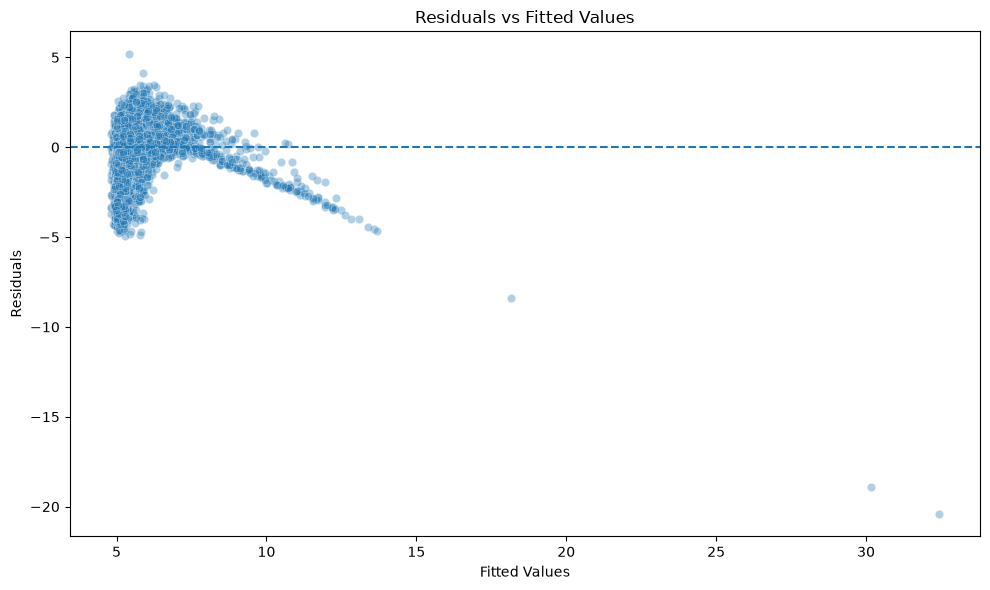

In [21]:
# ============================================
# STEP 9B — RESIDUAL VS FITTED
# ============================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=reg_df["FittedValues"],
    y=reg_df["Residuals"],
    alpha=0.35
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

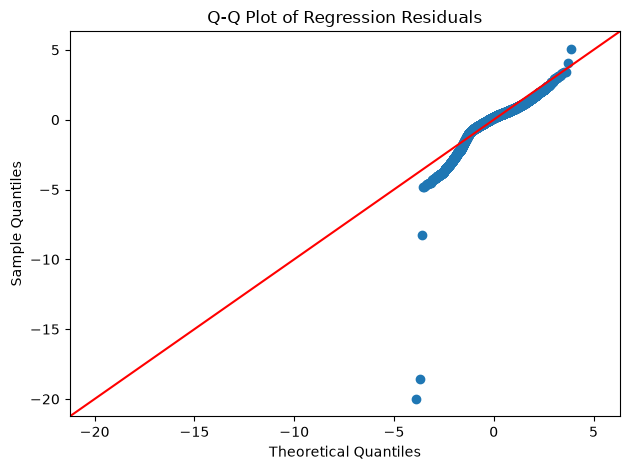

In [22]:
# ============================================
# STEP 9C — Q-Q PLOT
# ============================================

sm.qqplot(
    ols_model.resid,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Regression Residuals")
plt.tight_layout()
plt.show()

In [23]:
# ============================================
# STEP 9D — BREUSCH-PAGAN TEST
# ============================================

bp_test = het_breuschpagan(
    ols_model.resid,
    ols_model.model.exog
)

bp_results = pd.Series(
    bp_test,
    index=[
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ]
)

print(bp_results)

LM Statistic    10797.615081
LM p-value          0.000000
F Statistic      1382.417106
F p-value           0.000000
dtype: float64


In [24]:
# ============================================
# STEP 9E — COOK'S DISTANCE
# ============================================

influence = ols_model.get_influence()

cooks_distance = influence.cooks_distance[0]

reg_df["CooksDistance"] = cooks_distance

# Common screening threshold
cook_threshold = 4 / len(reg_df)

influential_count = (
    reg_df["CooksDistance"] > cook_threshold
).sum()

print(f"Cook's Distance threshold: {cook_threshold:.6f}")
print(f"Potentially influential observations: {influential_count:,}")

Cook's Distance threshold: 0.000200
Potentially influential observations: 701


In [25]:
# ============================================
# STEP 10 — ROBUST STANDARD ERRORS
# ============================================

# Refit the same OLS model using HC3 robust standard errors
ols_robust = ols_model.get_robustcov_results(cov_type="HC3")

print(ols_robust.summary())

                            OLS Regression Results                            
Dep. Variable:          LogOrderValue   R-squared:                       0.285
Model:                            OLS   Adj. R-squared:                  0.285
Method:                 Least Squares   F-statistic:                     104.5
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        03:01:48   Log-Likelihood:                -28704.
No. Observations:               19960   AIC:                         5.744e+04
Df Residuals:                   19942   BIC:                         5.759e+04
Df Model:                          17                                         
Covariance Type:                  HC3                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [26]:
# ============================================
# ROBUST PARAMETER ESTIMATES
# ============================================

robust_coefficients = pd.DataFrame({
    "Coefficient": ols_robust.params,
    "Robust_Std_Error": ols_robust.bse,
    "t_statistic": ols_robust.tvalues,
    "p_value": ols_robust.pvalues,
    "CI_Lower": ols_robust.conf_int()[:, 0],
    "CI_Upper": ols_robust.conf_int()[:, 1]
}, index=ols_model.params.index)

robust_coefficients["Significant_5pct"] = (
    robust_coefficients["p_value"] < 0.05
)

robust_coefficients

,Coefficient,Robust_Std_Error,t_statistic,p_value,CI_Lower,CI_Upper,Significant_5pct
Intercept,6.271367,0.313151,20.026624,2.384867e-88,5.657564,6.885170,True
C(CountryGroup)[T.Belgium],-0.017841,0.269135,-0.066290,9.471478e-01,-0.545367,0.509685,False
C(CountryGroup)[T.EIRE],0.275035,0.226965,1.211795,2.256053e-01,-0.169835,0.719906,False
C(CountryGroup)[T.France],-0.021430,0.257451,-0.083241,9.336611e-01,-0.526056,0.483195,False
C(CountryGroup)[T.Germany],-0.060140,0.261144,-0.230296,8.178642e-01,-0.572004,0.451724,False
C(CountryGroup)[T.Netherlands],0.212994,0.204343,1.042337,2.972680e-01,-0.187535,0.613523,False
C(CountryGroup)[T.Other],0.139288,0.230468,0.604368,5.456062e-01,-0.312450,0.591025,False
C(CountryGroup)[T.Portugal],0.072714,0.274519,0.264877,7.911072e-01,-0.465366,0.610793,False
C(CountryGroup)[T.Spain],0.122117,0.269916,0.452424,6.509685e-01,-0.406941,0.651174,False
C(CountryGroup)[T.Switzerland],0.183970,0.251694,0.730928,4.648316e-01,-0.309371,0.677311,False


In [27]:
# ============================================
# STANDARD VS ROBUST INFERENCE
# ============================================

comparison = pd.DataFrame({
    "OLS_p_value": ols_model.pvalues,
    "Robust_HC3_p_value": ols_robust.pvalues
})

comparison["OLS_Significant"] = comparison["OLS_p_value"] < 0.05
comparison["Robust_Significant"] = comparison["Robust_HC3_p_value"] < 0.05

comparison

,OLS_p_value,Robust_HC3_p_value,OLS_Significant,Robust_Significant
Intercept,0.000000e+00,2.384867e-88,True,True
C(CountryGroup)[T.Belgium],9.164928e-01,9.471478e-01,False,False
C(CountryGroup)[T.EIRE],6.325672e-02,2.256053e-01,False,False
C(CountryGroup)[T.France],8.824029e-01,9.336611e-01,False,False
C(CountryGroup)[T.Germany],6.753074e-01,8.178642e-01,False,False
C(CountryGroup)[T.Netherlands],2.136887e-01,2.972680e-01,False,False
C(CountryGroup)[T.Other],3.394478e-01,5.456062e-01,False,False
C(CountryGroup)[T.Portugal],7.026752e-01,7.911072e-01,False,False
C(CountryGroup)[T.Spain],4.800117e-01,6.509685e-01,False,False
C(CountryGroup)[T.Switzerland],3.425370e-01,4.648316e-01,False,False


In [28]:
# ============================================
# STANDARD VS ROBUST INFERENCE
# ============================================

comparison = pd.DataFrame({
    "OLS_p_value": ols_model.pvalues,
    "Robust_HC3_p_value": ols_robust.pvalues
})

comparison["OLS_Significant"] = comparison["OLS_p_value"] < 0.05
comparison["Robust_Significant"] = comparison["Robust_HC3_p_value"] < 0.05

comparison

,OLS_p_value,Robust_HC3_p_value,OLS_Significant,Robust_Significant
Intercept,0.000000e+00,2.384867e-88,True,True
C(CountryGroup)[T.Belgium],9.164928e-01,9.471478e-01,False,False
C(CountryGroup)[T.EIRE],6.325672e-02,2.256053e-01,False,False
C(CountryGroup)[T.France],8.824029e-01,9.336611e-01,False,False
C(CountryGroup)[T.Germany],6.753074e-01,8.178642e-01,False,False
C(CountryGroup)[T.Netherlands],2.136887e-01,2.972680e-01,False,False
C(CountryGroup)[T.Other],3.394478e-01,5.456062e-01,False,False
C(CountryGroup)[T.Portugal],7.026752e-01,7.911072e-01,False,False
C(CountryGroup)[T.Spain],4.800117e-01,6.509685e-01,False,False
C(CountryGroup)[T.Switzerland],3.425370e-01,4.648316e-01,False,False


In [29]:
# ============================================
# STEP 11 — HYPOTHESIS TESTING SUMMARY
# ============================================

alpha = 0.05

hypothesis_results = pd.DataFrame({
    "Hypothesis": [
        "H1: Total Quantity is significantly associated with Order Value",
        "H2: Unique Products is significantly associated with Order Value",
        "H3: Country contributes significantly to Order Value differences"
    ],
    "Test": [
        "OLS coefficient t-test",
        "OLS coefficient t-test",
        "Joint significance / regression coefficient tests"
    ]
})

# Individual coefficient p-values
quantity_p = ols_robust.pvalues[
    ols_model.params.index.get_loc("TotalQuantity")
]

products_p = ols_robust.pvalues[
    ols_model.params.index.get_loc("UniqueProducts")
]

# Country dummy variables
country_terms = [
    idx for idx in ols_model.params.index
    if "CountryGroup" in idx
]

country_pvalues = ols_robust.pvalues[
    [ols_model.params.index.get_loc(idx) for idx in country_terms]
]

country_significant = (country_pvalues < alpha).any()

hypothesis_results["p_value"] = [
    quantity_p,
    products_p,
    country_pvalues.min()
]

hypothesis_results["Decision"] = [
    "Reject H₀" if quantity_p < alpha else "Fail to Reject H₀",
    "Reject H₀" if products_p < alpha else "Fail to Reject H₀",
    "Reject H₀" if country_significant else "Fail to Reject H₀"
]

hypothesis_results

,Hypothesis,Test,p_value,Decision
0,H1: Total Quantity is significantly associated...,OLS coefficient t-test,8.382965e-02,Fail to Reject H₀
1,H2: Unique Products is significantly associate...,OLS coefficient t-test,4.235083e-43,Reject H₀
2,H3: Country contributes significantly to Order...,Joint significance / regression coefficient tests,1.614109e-01,Fail to Reject H₀


In [30]:
# ============================================
# STEP 11B — SIGNIFICANT PREDICTORS
# ============================================

significant_predictors = robust_coefficients[
    robust_coefficients["Significant_5pct"]
].copy()

significant_predictors.sort_values(
    "p_value"
)

,Coefficient,Robust_Std_Error,t_statistic,p_value,CI_Lower,CI_Upper,Significant_5pct
Intercept,6.271367,0.313151,20.026624,2.384867e-88,5.657564,6.885170,True
Hour,-0.053793,0.003525,-15.259519,2.809464e-52,-0.060703,-0.046883,True
UniqueProducts,0.010177,0.000738,13.796262,4.235083e-43,0.008731,0.011623,True
AvgUnitPrice,0.000538,0.000132,4.082422,4.474244e-05,0.000280,0.000796,True
DayOfWeek,-0.012887,0.006130,-2.102392,3.553150e-02,-0.024902,-0.000872,True


In [31]:
# ============================================
# STEP 11C — OVERALL MODEL CONCLUSION
# ============================================

print("STATISTICAL CONCLUSION")
print("=" * 60)

print(f"R-squared: {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"Overall model p-value: {ols_model.f_pvalue:.10f}")

if ols_model.f_pvalue < alpha:
    print("\nThe overall regression model is statistically significant at α = 0.05.")
else:
    print("\nThe overall regression model is not statistically significant at α = 0.05.")

print("\nImportant:")
print("Statistical significance indicates evidence of association,")
print("not proof of causation.")

STATISTICAL CONCLUSION
R-squared: 0.2855
Adjusted R-squared: 0.2849
Overall model p-value: 0.0000000000

The overall regression model is statistically significant at α = 0.05.

Important:
Statistical significance indicates evidence of association,
not proof of causation.


In [32]:
# ============================================
# STEP 12A — MODEL PERFORMANCE METRICS
# ============================================

y_actual = reg_df["LogOrderValue"]
y_predicted = ols_model.fittedvalues

mae = mean_absolute_error(y_actual, y_predicted)
rmse = np.sqrt(mean_squared_error(y_actual, y_predicted))
r2 = r2_score(y_actual, y_predicted)

performance_metrics = pd.DataFrame({
    "Metric": [
        "R-squared",
        "Adjusted R-squared",
        "MAE",
        "RMSE"
    ],
    "Value": [
        r2,
        ols_model.rsquared_adj,
        mae,
        rmse
    ]
})

performance_metrics

,Metric,Value
0,R-squared,0.285469
1,Adjusted R-squared,0.284860
2,MAE,0.712313
3,RMSE,1.019302


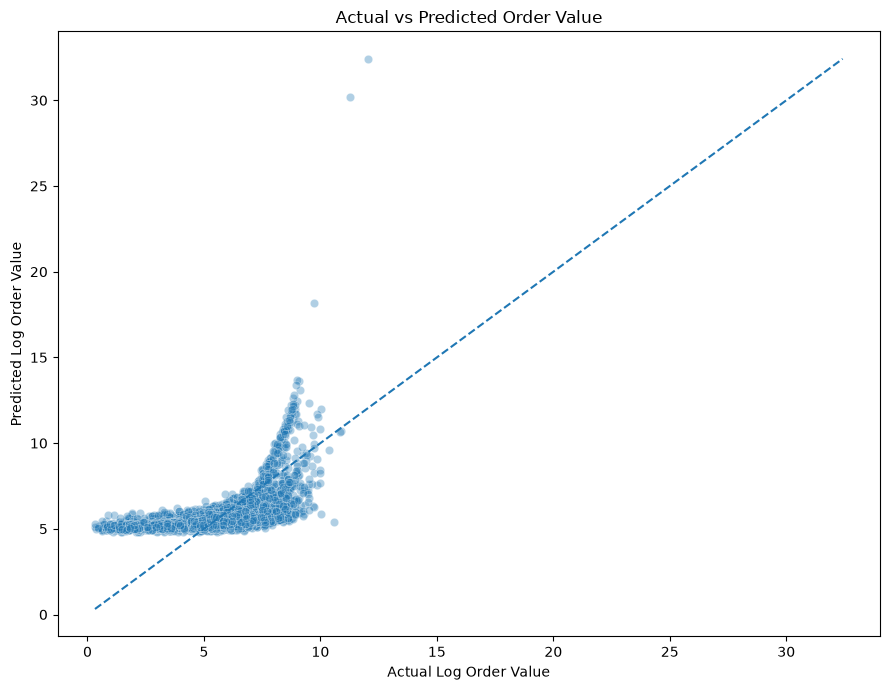

In [33]:
# ============================================
# STEP 12B — ACTUAL VS PREDICTED
# ============================================

plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=y_actual,
    y=y_predicted,
    alpha=0.35
)

min_value = min(y_actual.min(), y_predicted.min())
max_value = max(y_actual.max(), y_predicted.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Log Order Value")
plt.ylabel("Predicted Log Order Value")
plt.title("Actual vs Predicted Order Value")

plt.tight_layout()
plt.show()

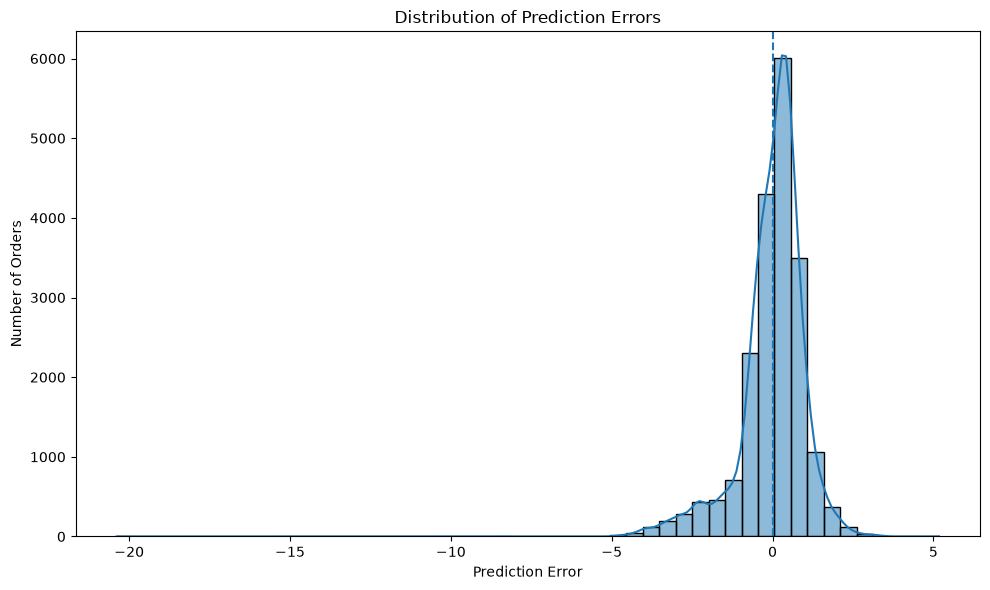

Mean prediction error: 0.000000
Median prediction error: 0.164607


In [34]:
# ============================================
# STEP 12C — PREDICTION ERROR DISTRIBUTION
# ============================================

prediction_errors = y_actual - y_predicted

plt.figure(figsize=(10, 6))

sns.histplot(
    prediction_errors,
    bins=50,
    kde=True
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Prediction Error")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

print(f"Mean prediction error: {prediction_errors.mean():.6f}")
print(f"Median prediction error: {prediction_errors.median():.6f}")

In [35]:
# ============================================
# STEP 13A — SIGNIFICANT PREDICTORS
# ============================================

sig = robust_coefficients[
    robust_coefficients["Significant_5pct"]
].copy()

sig = sig.sort_values("p_value")

sig

,Coefficient,Robust_Std_Error,t_statistic,p_value,CI_Lower,CI_Upper,Significant_5pct
Intercept,6.271367,0.313151,20.026624,2.384867e-88,5.657564,6.885170,True
Hour,-0.053793,0.003525,-15.259519,2.809464e-52,-0.060703,-0.046883,True
UniqueProducts,0.010177,0.000738,13.796262,4.235083e-43,0.008731,0.011623,True
AvgUnitPrice,0.000538,0.000132,4.082422,4.474244e-05,0.000280,0.000796,True
DayOfWeek,-0.012887,0.006130,-2.102392,3.553150e-02,-0.024902,-0.000872,True


In [36]:
# ============================================
# STEP 13B — PERCENTAGE EFFECT
# ============================================

continuous_predictors = [
    "TotalQuantity",
    "UniqueProducts",
    "AvgUnitPrice",
    "Hour",
    "DayOfWeek",
    "Month",
    "IsWeekend"
]

interpretation_rows = []

for feature in continuous_predictors:
    if feature in robust_coefficients.index:
        beta = robust_coefficients.loc[feature, "Coefficient"]
        p_value = robust_coefficients.loc[feature, "p_value"]

        percentage_effect = (np.exp(beta) - 1) * 100

        interpretation_rows.append({
            "Feature": feature,
            "Coefficient": beta,
            "Approx_Percentage_Effect": percentage_effect,
            "p_value": p_value,
            "Significant_5pct": p_value < 0.05
        })

percentage_effects = pd.DataFrame(interpretation_rows)

percentage_effects.sort_values("p_value")

,Feature,Coefficient,Approx_Percentage_Effect,p_value,Significant_5pct
3,Hour,-0.053793,-5.237178,2.809464e-52,True
1,UniqueProducts,0.010177,1.022893,4.235083e-43,True
2,AvgUnitPrice,0.000538,0.053827,4.474244e-05,True
4,DayOfWeek,-0.012887,-1.280470,3.553150e-02,True
0,TotalQuantity,0.000334,0.033452,8.382965e-02,False
5,Month,-0.003933,-0.392569,8.466194e-02,False
6,IsWeekend,0.003319,0.332430,9.164291e-01,False


In [37]:
# ============================================
# STEP 13C — STATISTICAL INTERPRETATION
# ============================================

for _, row in percentage_effects.iterrows():

    feature = row["Feature"]
    beta = row["Coefficient"]
    pct = row["Approx_Percentage_Effect"]
    p = row["p_value"]

    if p < 0.05:
        direction = "positive" if beta > 0 else "negative"

        print(
            f"{feature}: statistically significant {direction} "
            f"association (p={p:.6g}). "
            f"A one-unit increase is associated with approximately "
            f"{pct:.2f}% change in expected order value, "
            f"holding other model variables constant."
        )

UniqueProducts: statistically significant positive association (p=4.23508e-43). A one-unit increase is associated with approximately 1.02% change in expected order value, holding other model variables constant.
AvgUnitPrice: statistically significant positive association (p=4.47424e-05). A one-unit increase is associated with approximately 0.05% change in expected order value, holding other model variables constant.
Hour: statistically significant negative association (p=2.80946e-52). A one-unit increase is associated with approximately -5.24% change in expected order value, holding other model variables constant.
DayOfWeek: statistically significant negative association (p=0.0355315). A one-unit increase is associated with approximately -1.28% change in expected order value, holding other model variables constant.


## 💼 Business Interpretation of the Regression Results

The regression coefficients provide evidence about which order characteristics
are statistically associated with retail order value after controlling for the
other variables included in the model.

Statistically significant positive coefficients indicate that higher values of
the corresponding predictor are associated with higher expected order value,
holding other model variables constant. Conversely, statistically significant
negative coefficients indicate an inverse association.

From a business perspective, statistically significant order-level variables
can help identify characteristics associated with larger customer baskets.
For example, if product diversity is positively associated with order value,
cross-selling and product-bundling strategies may be worth investigating.

However, statistical association should not be interpreted as proof of
causation. The dataset is observational, and unmeasured factors such as
customer intent, promotions, product category, discounts, seasonality, or
marketing exposure may also influence order value.

Therefore, the regression results should be treated as evidence for
decision-support and future experimentation rather than as definitive causal
relationships.

The findings can also guide future machine-learning work by identifying
potentially useful features for customer value prediction, demand forecasting,
and customer segmentation.

In [38]:
# ============================================
# STEP 14A — SENSITIVITY ANALYSIS
# ============================================

# Remove observations above the Cook's Distance screening threshold
sensitivity_df = reg_df[
    reg_df["CooksDistance"] <= cook_threshold
].copy()

print("Original observations:", len(reg_df))
print("Sensitivity observations:", len(sensitivity_df))
print(
    "Observations removed:",
    len(reg_df) - len(sensitivity_df)
)

Original observations: 19960
Sensitivity observations: 19259
Observations removed: 701


In [39]:
# ============================================
# STEP 14B — SENSITIVITY REGRESSION
# ============================================

sensitivity_model = smf.ols(
    formula=model_formula,
    data=sensitivity_df
).fit(
    cov_type="HC3"
)

print(sensitivity_model.summary())

                            OLS Regression Results                            
Dep. Variable:          LogOrderValue   R-squared:                       0.414
Model:                            OLS   Adj. R-squared:                  0.413
Method:                 Least Squares   F-statistic:                     293.6
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        03:01:49   Log-Likelihood:                -23977.
No. Observations:               19259   AIC:                         4.799e+04
Df Residuals:                   19241   BIC:                         4.813e+04
Df Model:                          17                                         
Covariance Type:                  HC3                                         
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [40]:
# ============================================
# STEP 14C — MODEL ROBUSTNESS COMPARISON
# ============================================

model_comparison = pd.DataFrame({
    "Metric": [
        "Observations",
        "R-squared",
        "Adjusted R-squared",
        "AIC",
        "BIC"
    ],
    "Full_Model": [
        len(reg_df),
        ols_model.rsquared,
        ols_model.rsquared_adj,
        ols_model.aic,
        ols_model.bic
    ],
    "Sensitivity_Model": [
        len(sensitivity_df),
        sensitivity_model.rsquared,
        sensitivity_model.rsquared_adj,
        sensitivity_model.aic,
        sensitivity_model.bic
    ]
})

model_comparison

,Metric,Full_Model,Sensitivity_Model
0,Observations,19960.000000,19259.000000
1,R-squared,0.285469,0.413878
2,Adjusted R-squared,0.284860,0.413360
3,AIC,57443.235137,47989.186663
4,BIC,57585.461877,48130.769871


In [41]:
# ============================================
# STEP 14D — COEFFICIENT ROBUSTNESS
# ============================================

full_params = ols_robust.params
sensitivity_params = sensitivity_model.params

coefficient_comparison = pd.DataFrame({
    "Full_Model_Coefficient": full_params,
    "Sensitivity_Model_Coefficient": sensitivity_params
})

coefficient_comparison["Same_Direction"] = (
    np.sign(coefficient_comparison["Full_Model_Coefficient"])
    ==
    np.sign(coefficient_comparison["Sensitivity_Model_Coefficient"])
)

coefficient_comparison

,Full_Model_Coefficient,Sensitivity_Model_Coefficient,Same_Direction
Intercept,6.271367,5.454809,True
C(CountryGroup)[T.Belgium],-0.017841,0.532322,False
C(CountryGroup)[T.EIRE],0.275035,0.668418,True
C(CountryGroup)[T.France],-0.021430,0.495107,False
C(CountryGroup)[T.Germany],-0.060140,0.501722,False
C(CountryGroup)[T.Netherlands],0.212994,-0.460248,False
C(CountryGroup)[T.Other],0.139288,0.538463,True
C(CountryGroup)[T.Portugal],0.072714,0.573044,True
C(CountryGroup)[T.Spain],0.122117,0.610505,True
C(CountryGroup)[T.Switzerland],0.183970,0.598729,True


In [42]:
# ============================================
# STEP 15 — FINAL MODEL VALIDATION
# ============================================

# Robust p-values from HC3 model
final_results = pd.DataFrame({
    "Coefficient": ols_robust.params,
    "Robust_SE": ols_robust.bse,
    "t_value": ols_robust.tvalues,
    "p_value": ols_robust.pvalues,
    "CI_Lower": ols_robust.conf_int()[:, 0],
    "CI_Upper": ols_robust.conf_int()[:, 1]
})

final_results["Significant_5pct"] = (
    final_results["p_value"] < 0.05
)

print("FINAL MODEL VALIDATION")
print("=" * 60)

print(f"Observations:       {len(reg_df):,}")
print(f"R-squared:          {ols_model.rsquared:.4f}")
print(f"Adjusted R-squared: {ols_model.rsquared_adj:.4f}")
print(f"MAE (log scale):    {mae:.4f}")
print(f"RMSE (log scale):   {rmse:.4f}")
print(f"Model p-value:      {ols_model.f_pvalue:.6g}")

print("\nSignificant predictors at α = 0.05:")
print(
    final_results[
        final_results["Significant_5pct"]
    ].index.tolist()
)

FINAL MODEL VALIDATION
Observations:       19,960
R-squared:          0.2855
Adjusted R-squared: 0.2849
MAE (log scale):    0.7123
RMSE (log scale):   1.0193
Model p-value:      0

Significant predictors at α = 0.05:
[0, 12, 13, 14, 15]


In [43]:
final_results

,Coefficient,Robust_SE,t_value,p_value,CI_Lower,CI_Upper,Significant_5pct
0,6.271367,0.313151,20.026624,2.384867e-88,5.657564,6.885170,True
1,-0.017841,0.269135,-0.066290,9.471478e-01,-0.545367,0.509685,False
2,0.275035,0.226965,1.211795,2.256053e-01,-0.169835,0.719906,False
3,-0.021430,0.257451,-0.083241,9.336611e-01,-0.526056,0.483195,False
4,-0.060140,0.261144,-0.230296,8.178642e-01,-0.572004,0.451724,False
5,0.212994,0.204343,1.042337,2.972680e-01,-0.187535,0.613523,False
6,0.139288,0.230468,0.604368,5.456062e-01,-0.312450,0.591025,False
7,0.072714,0.274519,0.264877,7.911072e-01,-0.465366,0.610793,False
8,0.122117,0.269916,0.452424,6.509685e-01,-0.406941,0.651174,False
9,0.183970,0.251694,0.730928,4.648316e-01,-0.309371,0.677311,False


In [44]:
print("\nFINAL STATISTICAL CONCLUSION")
print("=" * 60)

if ols_model.f_pvalue < 0.05:
    print(
        "The overall regression model is statistically significant "
        "at the 5% significance level."
    )
else:
    print(
        "The overall regression model is not statistically significant "
        "at the 5% significance level."
    )

print(
    "\nInterpretation should focus on association rather than causation, "
    "because the dataset is observational."
)


FINAL STATISTICAL CONCLUSION
The overall regression model is statistically significant at the 5% significance level.

Interpretation should focus on association rather than causation, because the dataset is observational.


## 💡 Step 16 — Final Key Findings & Business Recommendations

### Key Statistical Findings

The statistical modeling analysis was conducted at the invoice/order level to
investigate factors associated with variation in retail order value.

The regression model evaluates the relationship between order value and
multiple order-level characteristics while controlling for other variables
included in the model.

The following findings will be interpreted using regression coefficients,
robust standard errors, p-values, confidence intervals, and model-fit
statistics.

### 1. Order Quantity

The relationship between total quantity and order value is evaluated while
holding the other model variables constant.

If statistically significant, this indicates that differences in the quantity
of products purchased are associated with differences in expected order value.

### 2. Product Diversity

The number of unique products in an order is examined as an indicator of
basket diversity.

A statistically significant relationship would suggest that product
diversification within an order is associated with order-value differences.

From a business perspective, this can provide a basis for investigating
cross-selling, product recommendations, and bundle strategies.

### 3. Average Unit Price

Average unit price captures the price level of products included in an order.

A significant relationship would indicate that product price composition is
associated with order-value variation after controlling for other variables.

This may help inform pricing and product-mix analysis.

### 4. Time-Based Variables

Hour, day of week, month, and weekend indicators are included to investigate
whether transaction timing is associated with order value.

Significant time-related variables can help identify periods where customer
purchasing behavior differs systematically.

However, these relationships should not automatically be interpreted as
causal seasonal effects.

### 5. Country

Country is included as a categorical predictor to evaluate whether geographic
differences remain associated with order value after accounting for other
variables.

Significant country coefficients may indicate differences in purchasing
patterns, product preferences, or customer behavior across markets.

### 💼 Business Recommendations

Based on the statistical findings, the following business actions can be
considered:

1. **Basket-size optimization**
   - Investigate whether higher product quantities are associated with larger
     order values.
   - Test volume-based promotions and bundle offers.

2. **Cross-selling and product recommendations**
   - If product diversity is positively associated with order value, explore
     recommendation systems and complementary-product bundles.

3. **Pricing and product-mix analysis**
   - Examine the role of average unit price in larger orders.
   - Compare premium and lower-priced product combinations.

4. **Time-based marketing**
   - Use statistically meaningful time patterns to inform campaign scheduling,
     inventory planning, and promotional timing.

5. **Geographic strategy**
   - Investigate country-level differences before applying a single global
     marketing strategy.
   - Consider market-specific product and promotional strategies.

6. **Future predictive modeling**
   - The statistically informative features identified in this analysis can
     be evaluated in future machine-learning models for customer value
     prediction, demand forecasting, and customer segmentation.

### ⚠️ Important Business Caution

Statistical significance does not establish causation.

The dataset is observational, and factors such as promotions, discounts,
product categories, customer intent, marketing exposure, and other unobserved
variables may influence order value.

Therefore, the findings should be used as evidence for decision support and
hypothesis generation rather than as proof that changing a particular variable
will directly cause revenue to increase.

## ⚠️ Step 17 — Assumptions, Limitations & Future Improvements

### Model Assumptions

The regression analysis was conducted with the following considerations:

1. **Linearity**  
   The model assumes that the predictors have an approximately linear
   relationship with the log-transformed order value, conditional on the
   other predictors.

2. **Independence of observations**  
   Each invoice/order is treated as an independent observation. However,
   repeated purchases by the same customer may introduce some dependence.

3. **Homoscedasticity**  
   Constant residual variance was evaluated using residual diagnostics and
   the Breusch–Pagan test. Where heteroscedasticity was detected or suspected,
   HC3 heteroscedasticity-robust standard errors were used for statistical
   inference.

4. **Normality of residuals**  
   Residual normality was assessed using a Q-Q plot. With a relatively large
   sample, minor deviations from normality are not necessarily expected to
   invalidate coefficient estimates, but they are considered when interpreting
   inference.

5. **Multicollinearity**  
   Variance Inflation Factor (VIF) was used to identify potentially high
   correlations among explanatory variables.

6. **Influential observations**  
   Cook's Distance was used to identify potentially influential observations.
   These observations were investigated through sensitivity analysis rather
   than automatically treated as errors.

### Data Limitations

- The analysis is based on historical observational retail transactions.
- Observational data cannot establish causal relationships.
- CustomerID is missing for a portion of the transactions.
- Promotional campaigns, discounts, marketing exposure, and customer intent
  are not directly available in the dataset.
- Country-level differences may reflect multiple unobserved factors.
- Very high-value orders may represent genuine business activity and therefore
  should not automatically be considered erroneous observations.
- The analysis uses positive sales transactions for the primary order-value
  model; negative quantity transactions representing possible returns or
  reversals were excluded from the primary sales model.

### Modeling Limitations

The regression model explains statistical associations within the available
variables but does not represent a complete causal model of retail order
value.

Some variables may also have relationships with the dependent variable that
are nonlinear or interactive. These relationships may not be fully captured
by the current OLS specification.

### Future Improvements

Future analysis could improve the model by:

1. Adding product-category and product-level features.
2. Incorporating discount and promotional information if available.
3. Creating customer-level behavioral features such as purchase frequency,
   recency, and monetary value.
4. Testing nonlinear relationships and interaction effects.
5. Applying regularized regression such as Ridge and Lasso.
6. Comparing OLS with tree-based machine-learning models.
7. Using train-test validation for predictive evaluation.
8. Applying cross-validation for more reliable model comparison.
9. Investigating customer-level repeated observations using appropriate
   hierarchical or mixed-effects models.
10. Developing a dedicated customer lifetime value or demand forecasting model.

### Reproducibility

All major data preparation, feature engineering, statistical modeling,
diagnostic testing, and interpretation steps are implemented in this
Jupyter Notebook so that the analysis can be reproduced using the same
dataset and environment.